In [10]:
from glob import glob

import cartopy.crs as ccrs
import numpy as np
import rasterio as rio
import rasterio.mask as rmask
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
import ultraplot as uplt


In [ ]:
print(len())

324


In [9]:
dest_crs = ccrs.AlbersEqualArea(central_longitude=-76.0, central_latitude=42.0,)

def prepare_for_viz(raster_file, dest_crs, mask_polygon=None):
    if mask_polygon is not None:
        orig_image, orig_transform = rmask.mask(raster_file, [mask_polygon], crop=True)
    else:
        orig_image = raster_file.read()
        orig_transform = raster_file.transform
        
    transform, width, height = calculate_default_transform(
        raster_file.crs, dest_crs, raster_file.width, raster_file.height, *raster_file.bounds)
    
    new_image, new_transform = reproject(
        source=orig_image,
        src_transform=orig_transform,
        src_crs=raster_file.crs,
        dst_crs=dest_crs,
        resampling=Resampling.nearest,
        dst_nodata=np.nan)
    
    new_bounds = array_bounds(new_image.shape[1], new_image.shape[2], new_transform)
    #new_image = np.concatenate([new_image, new_image, new_image])
    new_image = new_image.transpose([1, 2, 0])
    
    # Create a nan mask
    alpha_channel = ~np.isnan(new_image[:, :, [0]])
    new_image = np.concatenate([new_image, alpha_channel], axis=2)

    return new_image, new_bounds

# arnot_forest_1_reproj, arnot_forest_1_reproj_bounds = prepare_for_viz(arnot_forest_1, dest_crs)
# arnot_forest_2_reproj, arnot_forest_2_reproj_bounds = prepare_for_viz(arnot_forest_2, dest_crs)
# arnot_forest_3_reproj, arnot_forest_3_reproj_bounds = prepare_for_viz(arnot_forest_3, dest_crs)

BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=51.0737154786154, right=-93.07893816404423, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.52287312067516)
BoundingBox(left=-93.52809580610399, bottom=50.62455783655564, right=-92.62978052198447, top=51.522873120

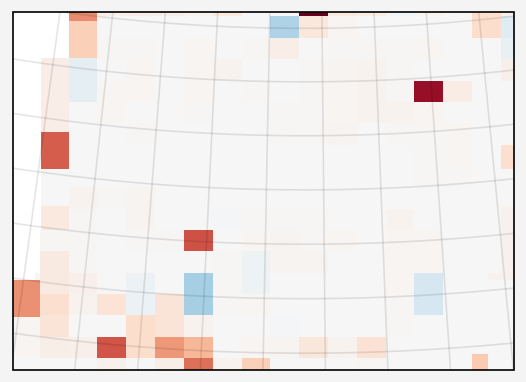

In [16]:
fig, ax = uplt.subplots(proj=dest_crs)


for path in glob("../data/pheno_params/*.tif"):
    with rio.open(path) as src:
        image, bounds = prepare_for_viz(src, dest_crs)
        print(src.bounds)
        ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs)

ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


ValueError: EPSG code does not define a projection